# Setup

In [ ]:
# Kaggle setup + dataset download
import os
from kaggle_secrets import UserSecretsClient

# Pull token from secrets (avoids putting it in the notebook)
secrets = UserSecretsClient()
token = secrets.get_secret('KAGGLE_API_TOKEN')

# Write to the location the kaggle CLI expects
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/access_token'), 'w') as f:
    f.write(token)
os.chmod(os.path.expanduser('~/.kaggle/access_token'), 0o600)

SAVE_DIR = '/kaggle/working'
DATA_DIR = '/kaggle/working/ShapeNet/raw'
EXTRACTED = os.path.join(DATA_DIR, 'shapenetcore_partanno_segmentation_benchmark_v0_normal')

if not os.path.exists(EXTRACTED) and not os.path.exists(os.path.join(DATA_DIR, '02691156')):
    os.makedirs(DATA_DIR, exist_ok=True)
    print('Downloading ShapeNet from Kaggle (~1.3 GB)...')
    !kaggle datasets download -d mitkir/shapenet -p {DATA_DIR} --unzip
    print('Download complete.')
else:
    print('Dataset already present.')

!pip install torch-geometric -q
print('Setup done.')

print('\nContents of raw/:')
print(sorted(os.listdir(DATA_DIR))[:20])

Dataset already present.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.4 MB/s eta 0:00:00a 0:00:01
Setup done.

Contents of raw/:
['.ipynb_checkpoints', '02691156', '02773838', '02954340', '02958343', '03001627', '03261776', '03467517', '03624134', '03636649', '03642806', '03790512', '03797390', '03948459', '04099429', '04225987', '04379243', 'synsetoffset2category.txt', 'train_test_split', 'util']


In [ ]:
# The Kaggle ShapeNet download extracts into a nested subfolder so move everything up one level so PyG can find it.

import os, shutil

RAW_DIR = '/kaggle/working/ShapeNet/raw'
NESTED  = os.path.join(RAW_DIR, 'shapenetcore_partanno_segmentation_benchmark_v0_normal')

if os.path.isdir(NESTED):
    print('Flattening nested folder...')
    for item in os.listdir(NESTED):
        src = os.path.join(NESTED, item)
        dst = os.path.join(RAW_DIR, item)
        if not os.path.exists(dst):
            shutil.move(src, dst)
    try:
        os.rmdir(NESTED)
    except OSError:
        pass
    print('Done.')
else:
    print('Already flat.')

print('\nraw/ contents:')
print(sorted(os.listdir(RAW_DIR))[:20])

Already flat.

raw/ contents:
['.ipynb_checkpoints', '02691156', '02773838', '02954340', '02958343', '03001627', '03261776', '03467517', '03624134', '03636649', '03642806', '03790512', '03797390', '03948459', '04099429', '04225987', '04379243', 'synsetoffset2category.txt', 'train_test_split', 'util']


In [ ]:
# Imports

import os, json, time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch_geometric.datasets import ShapeNet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [ ]:
# Constants

SEG_CLASSES = {
    'Airplane':   [0,1,2,3], 'Bag':       [4,5],    'Cap':       [6,7],
    'Car':        [8,9,10,11],'Chair':    [12,13,14,15],'Earphone':[16,17,18],
    'Guitar':     [19,20,21], 'Knife':    [22,23],   'Lamp':      [24,25,26,27],
    'Laptop':     [28,29],    'Motorbike':[30,31,32,33,34,35],'Mug':[36,37],
    'Pistol':     [38,39,40], 'Rocket':   [41,42,43],'Skateboard':[44,45,46],
    'Table':      [47,48,49],
}
ALL_CATEGORIES = list(SEG_CLASSES.keys())
NUM_CATEGORIES = 16
NUM_PARTS = 50

# Dataset

In [ ]:
class ShapeNetPartSeg(Dataset):
    def __init__(self, root, split='train', categories=None, augment=False, npoints=2048):
        assert split in ('train', 'val', 'test')
        self.augment = augment and (split == 'train')
        self.npoints = npoints
        pyg_split = 'trainval' if split == 'train' else split
        self.dataset = ShapeNet(root=root, categories=categories,
                                split=pyg_split, include_normals=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]
        xyz     = data.pos.numpy()
        normals = data.x.numpy()
        labels  = data.y.numpy().astype(np.int64)

        # subsample or pad to fixed point count
        N = xyz.shape[0]
        if N >= self.npoints:
            choice = np.random.choice(N, self.npoints, replace=False)
        else:
            choice = np.random.choice(N, self.npoints, replace=True)
        xyz, normals, labels = xyz[choice], normals[choice], labels[choice]

        # get integer category index from PyG's one-hot or scalar format
        cat_idx = int(data.category[0].argmax().item()) if data.category.dim() == 2 \
                  else int(data.category.item())
        if self.augment:
            xyz, normals = self._augment(xyz, normals)

        # stack xyz + normals into 6-channel input
        points = np.concatenate([xyz, normals], axis=1)

        # one-hot category vector fed to the model alongside the points
        cat_oh = np.zeros(NUM_CATEGORIES, dtype=np.float32)
        cat_oh[cat_idx] = 1.0
        return (torch.from_numpy(points).float(),
                torch.from_numpy(labels).long(),
                cat_idx,
                torch.from_numpy(cat_oh).float())

    @staticmethod
    def _augment(xyz, normals):
        # random Y-axis rotation + small gaussian jitter
        theta = np.random.uniform(0, 2*np.pi)
        R = np.array([[np.cos(theta),0,np.sin(theta)],[0,1,0],
                       [-np.sin(theta),0,np.cos(theta)]], dtype=np.float32)
        xyz = np.clip(xyz @ R.T + np.random.normal(0,.01,xyz.shape).astype(np.float32), -1, 1)
        return xyz, normals @ R.T


def get_dataloaders(root, batch_size=16, num_workers=2, categories=None):
    kw = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=True)
    train_ds = ShapeNetPartSeg(root, 'train', categories, augment=True)
    val_ds   = ShapeNetPartSeg(root, 'val',   categories, augment=False)
    test_ds  = ShapeNetPartSeg(root, 'test',  categories, augment=False)
    print(f'Dataset — train:{len(train_ds)} val:{len(val_ds)} test:{len(test_ds)}')
    return (DataLoader(train_ds, shuffle=True,  **kw),
            DataLoader(val_ds,   shuffle=False, **kw),
            DataLoader(test_ds,  shuffle=False, **kw))

# PointNet Model

In [ ]:
class TNet(nn.Module):
    def __init__(self, k):
        super().__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k,   64,   1); self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64,  128,  1); self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 1024, 1); self.bn3 = nn.BatchNorm1d(1024)
        self.fc1   = nn.Linear(1024, 512);    self.bn4 = nn.BatchNorm1d(512)
        self.fc2   = nn.Linear(512,  256);    self.bn5 = nn.BatchNorm1d(256)
        self.fc3   = nn.Linear(256,  k*k)

    def forward(self, x):
        B = x.shape[0]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.fc1(x.max(-1)[0])))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)
        I = torch.eye(self.k, device=x.device).view(1,-1).expand(B,-1)
        return (x + I).view(B, self.k, self.k)


class PointNet(nn.Module):
    """PointNet for part segmentation (Qi et al., CVPR 2017)"""
    def __init__(self, num_parts=50, num_categories=16, use_normals=True, dropout=0.4):
        super().__init__()
        in_ch = 6 if use_normals else 3
        self.use_normals = use_normals
        self.tnet_in   = TNet(in_ch)
        self.conv1     = nn.Conv1d(in_ch, 64,  1); self.bn1 = nn.BatchNorm1d(64)
        self.conv2     = nn.Conv1d(64,  128,   1); self.bn2 = nn.BatchNorm1d(128)
        self.conv3     = nn.Conv1d(128, 128,   1); self.bn3 = nn.BatchNorm1d(128)
        self.tnet_feat = TNet(128)
        self.conv4     = nn.Conv1d(128, 512,   1); self.bn4 = nn.BatchNorm1d(512)
        self.conv5     = nn.Conv1d(512, 2048,  1); self.bn5 = nn.BatchNorm1d(2048)
        seg_in = 2048 + 128 + num_categories
        self.seg1 = nn.Conv1d(seg_in, 256, 1); self.sbn1 = nn.BatchNorm1d(256)
        self.seg2 = nn.Conv1d(256,    256, 1); self.sbn2 = nn.BatchNorm1d(256)
        self.seg3 = nn.Conv1d(256,    128, 1); self.sbn3 = nn.BatchNorm1d(128)
        self.seg4 = nn.Conv1d(128, num_parts, 1)
        self.drop = nn.Dropout(dropout)

    def forward(self, points, cat_oh):
        B, N, _ = points.shape
        x = points[:, :, :6 if self.use_normals else 3].transpose(2,1)
        x = torch.bmm(self.tnet_in(x), x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        local_feat = x
        x = torch.bmm(self.tnet_feat(x), x)
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        gf  = x.max(-1)[0].unsqueeze(-1).expand(-1,-1,N)
        cat = cat_oh.unsqueeze(-1).expand(-1,-1,N)
        x = torch.cat([gf, local_feat, cat], 1)
        x = F.relu(self.sbn1(self.seg1(x)))
        x = F.relu(self.sbn2(self.seg2(x)))
        x = self.drop(x)
        x = F.relu(self.sbn3(self.seg3(x)))
        return self.seg4(x).transpose(2,1)

    def reg_loss(self, points, weight=0.001):
        x = points.transpose(2,1)
        x = torch.bmm(self.tnet_in(x), x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        T = self.tnet_feat(x)
        I = torch.eye(T.shape[1], device=T.device).unsqueeze(0)
        return weight * torch.norm(torch.bmm(T, T.transpose(2,1)) - I, dim=(1,2)).mean()

# PointNet++ Model

In [ ]:
def sq_dist(src, dst):
    d = -2*torch.bmm(src, dst.permute(0,2,1))
    d += (src**2).sum(-1,keepdim=True)
    d += (dst**2).sum(-1).unsqueeze(1)
    return d.clamp(min=0)

def fps(xyz, n):
    B, N, _ = xyz.shape
    dev = xyz.device
    idx = torch.zeros(B, n, dtype=torch.long, device=dev)
    dist = torch.full((B,N), float('inf'), device=dev)
    far  = torch.randint(0, N, (B,), device=dev)
    for i in range(n):
        idx[:,i] = far
        c = xyz[torch.arange(B,device=dev), far].unsqueeze(1)
        dist = torch.min(dist, ((xyz-c)**2).sum(-1))
        far  = dist.argmax(-1)
    return idx

def idx_pts(pts, idx):
    B, raw = pts.shape[0], idx.shape
    f = idx.reshape(B,-1)
    return pts.gather(1, f.unsqueeze(-1).expand(-1,-1,pts.shape[-1])).view(B,*raw,pts.shape[-1])

def ball_q(r, k, xyz, new_xyz):
    sd  = sq_dist(new_xyz, xyz)
    gi  = sd.argsort(-1)[:,:,:k]
    bad = sd.gather(2, gi) > r**2
    gi[bad] = gi[:,:,0:1].expand_as(gi)[bad]
    return gi

def mlp1d(ch, bn=True):
    layers = []
    for i in range(len(ch)-1):
        layers += [nn.Conv1d(ch[i],ch[i+1],1)] + ([nn.BatchNorm1d(ch[i+1])] if bn else []) + [nn.ReLU(True)]
    return nn.Sequential(*layers)

class SA(nn.Module):
    def __init__(self, S, r, k, in_ch, mlp):
        super().__init__()
        self.S, self.r, self.k = S, r, k
        self.mlp = mlp1d([in_ch+3]+mlp)
    def forward(self, xyz, feat):
        B, N, _ = xyz.shape
        ci  = fps(xyz, self.S);   nxyz = idx_pts(xyz, ci)
        gi  = ball_q(self.r, self.k, xyz, nxyz)
        gxyz = idx_pts(xyz, gi) - nxyz.unsqueeze(2)
        gp = torch.cat([gxyz, idx_pts(feat, gi)], -1) if feat is not None else gxyz
        B2, S, K, D = gp.shape
        x = self.mlp(gp.view(B2*S, K, D).transpose(2,1)).max(-1)[0]
        return nxyz, x.view(B2, S, -1)

class GSA(nn.Module):
    def __init__(self, in_ch, mlp):
        super().__init__()
        self.mlp = mlp1d([in_ch+3]+mlp)
    def forward(self, xyz, feat):
        B = xyz.shape[0]
        x = torch.cat([xyz, feat], -1) if feat is not None else xyz
        x = self.mlp(x.transpose(2,1)).max(-1)[0]
        return torch.zeros(B, 1, 3, device=xyz.device), x.unsqueeze(1)

class FP(nn.Module):
    def __init__(self, in_ch, mlp):
        super().__init__()
        self.mlp = mlp1d([in_ch]+mlp)
    def forward(self, xyz1, xyz2, f1, f2):
        B, N1, _ = xyz1.shape
        if xyz2.shape[1] == 1:
            interp = f2.expand(-1, N1, -1)
        else:
            d, ix = sq_dist(xyz1, xyz2).topk(3, dim=-1, largest=False)
            w = (d+1e-10).reciprocal(); w = w / w.sum(-1, keepdim=True)
            interp = (idx_pts(f2, ix) * w.unsqueeze(-1)).sum(2)
        x = torch.cat([f1, interp], -1) if f1 is not None else interp
        return self.mlp(x.transpose(2,1)).transpose(2,1)

class PointNet2(nn.Module):
    """PointNet++ SSG for part segmentation (Qi et al., NeurIPS 2017)"""
    def __init__(self, num_parts=50, num_categories=16, use_normals=True, dropout=0.5):
        super().__init__()
        nc = 3 if use_normals else 0
        self.use_normals = use_normals
        self.sa1 = SA(512, 0.2, 32, nc, [64,64,128])
        self.sa2 = SA(128, 0.4, 64, 128, [128,128,256])
        self.sa3 = GSA(256, [256,512,1024])
        self.fp3 = FP(1024+256, [256,256])
        self.fp2 = FP(256+128,  [256,128])
        self.fp1 = FP(128+nc+num_categories, [128,128])
        self.out = nn.Sequential(
            nn.Conv1d(128,128,1), nn.BatchNorm1d(128), nn.ReLU(True),
            nn.Dropout(dropout), nn.Conv1d(128,num_parts,1))

    def forward(self, points, cat_oh):
        B, N, _ = points.shape
        xyz = points[:,:,:3]
        nor = points[:,:,3:] if self.use_normals else None
        xyz1, f1 = self.sa1(xyz, nor)
        xyz2, f2 = self.sa2(xyz1, f1)
        xyz3, f3 = self.sa3(xyz2, f2)
        f2 = self.fp3(xyz2, xyz3, f2, f3)
        f1 = self.fp2(xyz1, xyz2, f1, f2)
        cat_exp = cat_oh.unsqueeze(1).expand(-1, N, -1)
        skip = torch.cat([nor, cat_exp], -1) if nor is not None else cat_exp
        f0 = self.fp1(xyz, xyz1, skip, f1)
        return self.out(f0.transpose(2,1)).transpose(2,1)

# DGCNN Model

In [ ]:
def knn_idx(x, k):
    inner = -2*torch.bmm(x.transpose(2,1), x)
    sq = (x**2).sum(1, keepdim=True)
    dist = sq + sq.transpose(2,1) + inner
    return dist.topk(k+1, dim=-1, largest=False)[1][:,:,1:]

def graph_feat(x, k):
    B, C, N = x.shape
    idx = knn_idx(x, k)
    base = torch.arange(B, device=x.device).view(-1,1,1) * N
    flat = (idx+base).view(B, -1)
    xt = x.transpose(2,1).contiguous().view(B*N, C)
    nbr  = xt[flat].view(B, N, k, C)
    self_ = x.transpose(2,1).unsqueeze(2).expand(-1, -1, k, -1)
    return torch.cat([self_, nbr-self_], -1).permute(0,3,1,2)

class EC(nn.Module):
    def __init__(self, in_ch, out_ch, k=20):
        super().__init__()
        self.k = k
        self.m = nn.Sequential(
            nn.Conv2d(in_ch*2, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.LeakyReLU(.2, True),
            nn.Conv2d(out_ch,  out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.LeakyReLU(.2, True))
    def forward(self, x):
        return self.m(graph_feat(x, self.k)).max(-1)[0]

class DGCNN(nn.Module):
    """DGCNN for part segmentation (Wang et al., TOG 2019)"""
    def __init__(self, num_parts=50, num_categories=16, k=20,
                 use_normals=True, emb_dims=1024, dropout=0.5):
        super().__init__()
        in_ch = 6 if use_normals else 3
        self.use_normals = use_normals
        self.ec1 = EC(in_ch, 64, k);  self.ec2 = EC(64, 64, k)
        self.ec3 = EC(64, 64, k);     self.ec4 = EC(64, 128, k)
        self.agg = nn.Sequential(
            nn.Conv1d(320, emb_dims, 1, bias=False), nn.BatchNorm1d(emb_dims), nn.LeakyReLU(.2, True))
        seg_in = emb_dims + 320 + num_categories
        self.seg = nn.Sequential(
            nn.Conv1d(seg_in, 256, 1, bias=False), nn.BatchNorm1d(256), nn.LeakyReLU(.2, True), nn.Dropout(dropout),
            nn.Conv1d(256,    256, 1, bias=False), nn.BatchNorm1d(256), nn.LeakyReLU(.2, True), nn.Dropout(dropout),
            nn.Conv1d(256,    128, 1, bias=False), nn.BatchNorm1d(128), nn.LeakyReLU(.2, True),
            nn.Conv1d(128, num_parts, 1))

    def forward(self, points, cat_oh):
        B, N, _ = points.shape
        x = points[:, :, :6 if self.use_normals else 3].transpose(2,1)
        x1 = self.ec1(x); x2 = self.ec2(x1); x3 = self.ec3(x2); x4 = self.ec4(x3)
        loc = torch.cat([x1, x2, x3, x4], 1)
        gf  = self.agg(loc).max(-1)[0].unsqueeze(-1).expand(-1, -1, N)
        cat = cat_oh.unsqueeze(-1).expand(-1, -1, N)
        return self.seg(torch.cat([gf, loc, cat], 1)).transpose(2,1)

# Metrics

In [ ]:
def shape_iou(pred, true, cat_idx):
    parts = SEG_CLASSES[ALL_CATEGORIES[cat_idx]]
    ious = []
    for p in parts:
        pm, tm = pred==p, true==p
        union = (pm|tm).sum()
        ious.append(1.0 if union==0 else (pm&tm).sum()/union)
    return float(np.mean(ious))

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    cat_ious = {i: [] for i in range(NUM_CATEGORIES)}
    correct = total = 0
    for pts, lbl, cats, oh in loader:
        logits = model(pts.to(DEVICE), oh.to(DEVICE))
        preds  = logits.argmax(-1).cpu().numpy()
        lbl_np = lbl.numpy()
        for b in range(preds.shape[0]):
            cat_ious[int(cats[b])].append(shape_iou(preds[b], lbl_np[b], int(cats[b])))
        correct += (preds==lbl_np).sum()
        total   += preds.size
    all_ious, per_cat = [], {}
    for i, name in enumerate(ALL_CATEGORIES):
        if cat_ious[i]:
            per_cat[name] = float(np.mean(cat_ious[i]))
            all_ious.extend(cat_ious[i])
    return (float(np.mean(all_ious)),
            float(np.mean(list(per_cat.values()))),
            per_cat,
            correct/max(total,1))

# Training Function (with auto-resume)

In [ ]:
def train_model(model, model_name, train_loader, val_loader,
                epochs=100, lr=1e-3, weight_decay=1e-4,
                label_smooth=0.2, use_reg=False, resume=True):

    ckpt_dir = os.path.join(SAVE_DIR, 'checkpoints', model_name)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, 'best_model.pt')

    history = {'train_loss': [], 'val_miou': []}
    best_miou = 0.0
    start_epoch = 1

    if resume and os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['state_dict'])
        start_epoch = ckpt['epoch'] + 1
        best_miou = ckpt['miou']
        hist_path = os.path.join(ckpt_dir, 'history.json')
        if os.path.exists(hist_path):
            with open(hist_path) as f:
                history = json.load(f)
        print(f'Resuming {model_name} from epoch {start_epoch}, best mIoU so far: {best_miou*100:.2f}%')

    if start_epoch > epochs:
        print(f'Already trained for {epochs} epochs. Skipping.')
        return history

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

    for epoch in range(start_epoch, epochs+1):
        model.train()
        total_loss, n = 0.0, 0
        for pts, lbl, _, oh in train_loader:
            pts, lbl, oh = pts.to(DEVICE), lbl.to(DEVICE), oh.to(DEVICE)
            optimizer.zero_grad()
            logits = model(pts, oh)
            loss = criterion(logits.reshape(-1, NUM_PARTS), lbl.reshape(-1))
            if use_reg:
                loss = loss + model.reg_loss(pts)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            n += 1
        scheduler.step()

        train_loss = total_loss / max(n, 1)
        inst_miou, cat_miou, per_cat, acc = evaluate(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_miou'].append(inst_miou)

        with open(os.path.join(ckpt_dir, 'history.json'), 'w') as f:
            json.dump(history, f)

        print(f'[{model_name}] Epoch {epoch:03d}/{epochs}  '
              f'loss={train_loss:.4f}  '
              f'mIoU={inst_miou*100:.2f}%  '
              f'cat_mIoU={cat_miou*100:.2f}%  '
              f'acc={acc*100:.2f}%')

        if inst_miou > best_miou:
            best_miou = inst_miou
            torch.save({'epoch': epoch, 'state_dict': model.state_dict(),
                        'miou': inst_miou, 'per_cat': per_cat},
                       ckpt_path)
            print(f'  New best: {best_miou*100:.2f}%')

    print(f'\nDone! Best val mIoU: {best_miou*100:.2f}%')
    return history

# Build Dataloaders

In [ ]:
DATA_ROOT = '/kaggle/working/ShapeNet'
BATCH_SIZE = 16

train_loader, val_loader, test_loader = get_dataloaders(
    root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    num_workers=2,
    categories=None,
)

pts, lbl, cat, oh = next(iter(train_loader))
assert pts.shape == (16, 2048, 6), f'Bad shape: {pts.shape}'
assert lbl.max() < 50
print(f'✓ Sanity check passed. points={pts.shape}, labels=[0, {lbl.max()}]')

Dataset — train:14007 val:1870 test:2874
✓ Sanity check passed. points=torch.Size([16, 2048, 6]), labels=[0, 49]


# Train PointNet

In [ ]:
pointnet = PointNet(num_parts=NUM_PARTS, num_categories=NUM_CATEGORIES,
                    use_normals=True, dropout=0.4).to(DEVICE)
n_params = sum(p.numel() for p in pointnet.parameters())
print(f'PointNet parameters: {n_params:,}')

history_pn = train_model(
    model=pointnet,
    model_name='pointnet',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    use_reg=True,
)

PointNet parameters: 7,645,206
Resuming pointnet from epoch 50, best mIoU so far: 83.63%
[pointnet] Epoch 050/50  loss=1.4426  mIoU=82.68%  cat_mIoU=73.87%  acc=92.84%

Done! Best val mIoU: 83.63%


In [ ]:
# Gather points/features by index. pts: [B, N, D], idx: [B, ...] returns [B, ..., D]
def idx_pts(pts, idx):
    B = pts.shape[0]
    D = pts.shape[-1]
    out_shape = list(idx.shape) + [D]
    f = idx.reshape(B, -1)
    gathered = pts.gather(1, f.unsqueeze(-1).expand(-1, -1, D))
    return gathered.reshape(*out_shape)

print('idx_pts patched.')

idx_pts patched.


# Train PointNet++

In [ ]:
pointnet2 = PointNet2(num_parts=NUM_PARTS, num_categories=NUM_CATEGORIES,
                      use_normals=True, dropout=0.5).to(DEVICE)
n_params = sum(p.numel() for p in pointnet2.parameters())
print(f'PointNet++ parameters: {n_params:,}')

history_pn2 = train_model(
    model=pointnet2,
    model_name='pointnet2',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
)

PointNet++ parameters: 1,394,098
Resuming pointnet2 from epoch 49, best mIoU so far: 86.07%
[pointnet2] Epoch 049/50  loss=1.4688  mIoU=83.42%  cat_mIoU=74.43%  acc=93.73%
[pointnet2] Epoch 050/50  loss=1.4666  mIoU=82.97%  cat_mIoU=71.88%  acc=93.16%

Done! Best val mIoU: 86.07%


# Train DGCNN

In [ ]:
dgcnn = DGCNN(num_parts=NUM_PARTS, num_categories=NUM_CATEGORIES,
              k=20, use_normals=True, dropout=0.5).to(DEVICE)
n_params = sum(p.numel() for p in dgcnn.parameters())
print(f'DGCNN parameters: {n_params:,}')

history_dgcnn = train_model(
    model=dgcnn,
    model_name='dgcnn',
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
)

DGCNN parameters: 847,410
Resuming dgcnn from epoch 37, best mIoU so far: 83.94%
[dgcnn] Epoch 037/50  loss=1.4463  mIoU=82.52%  cat_mIoU=71.31%  acc=93.20%
[dgcnn] Epoch 038/50  loss=1.4470  mIoU=82.89%  cat_mIoU=70.55%  acc=93.36%
[dgcnn] Epoch 039/50  loss=1.4461  mIoU=82.82%  cat_mIoU=69.84%  acc=93.35%
[dgcnn] Epoch 040/50  loss=1.4443  mIoU=81.80%  cat_mIoU=71.80%  acc=93.31%
[dgcnn] Epoch 041/50  loss=1.4443  mIoU=82.85%  cat_mIoU=73.15%  acc=93.52%
[dgcnn] Epoch 042/50  loss=1.4447  mIoU=83.28%  cat_mIoU=72.64%  acc=93.68%
[dgcnn] Epoch 043/50  loss=1.4431  mIoU=83.22%  cat_mIoU=71.66%  acc=93.62%
[dgcnn] Epoch 044/50  loss=1.4425  mIoU=83.25%  cat_mIoU=70.37%  acc=93.34%
[dgcnn] Epoch 045/50  loss=1.4421  mIoU=83.08%  cat_mIoU=71.91%  acc=93.22%
[dgcnn] Epoch 046/50  loss=1.4409  mIoU=83.27%  cat_mIoU=71.34%  acc=93.56%
[dgcnn] Epoch 047/50  loss=1.4412  mIoU=83.45%  cat_mIoU=73.40%  acc=93.55%
[dgcnn] Epoch 048/50  loss=1.4396  mIoU=83.44%  cat_mIoU=72.84%  acc=93.60%
[dgcnn]

# Test-set Evaluation

In [ ]:
def load_best(ModelClass, name, **kwargs):
    path = os.path.join(SAVE_DIR, 'checkpoints', name, 'best_model.pt')
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    m = ModelClass(**kwargs).to(DEVICE)
    m.load_state_dict(ckpt['state_dict'])
    m.eval()
    print(f'Loaded {name} — val mIoU {ckpt["miou"]*100:.2f}% (epoch {ckpt["epoch"]})')
    return m

kw = dict(num_parts=NUM_PARTS, num_categories=NUM_CATEGORIES, use_normals=True)
models = {
    'PointNet':   load_best(PointNet,  'pointnet',  dropout=0.0, **kw),
    'PointNet++': load_best(PointNet2, 'pointnet2', dropout=0.0, **kw),
    'DGCNN':      load_best(DGCNN,     'dgcnn',     dropout=0.0, **kw),
}

results = {}
for name, model in models.items():
    inst, cat, per_cat, acc = evaluate(model, test_loader)
    results[name] = dict(instance_miou=inst, cat_miou=cat, per_cat=per_cat, acc=acc)
    print(f'{name:<12} inst-mIoU={inst*100:.2f}%  cat-mIoU={cat*100:.2f}%  acc={acc*100:.2f}%')

# Save results to disk for the report
with open(os.path.join(SAVE_DIR, 'results.json'), 'w') as f:
    json.dump({k: {kk: vv for kk, vv in v.items()} for k, v in results.items()}, f, indent=2)

# Summary table
print('\n' + '='*55)
print(f'{"Model":<14} {"Inst-mIoU":>11} {"Cat-mIoU":>10} {"Pt-Acc":>10}')
print('-'*55)
for name, r in results.items():
    print(f'{name:<14} {r["instance_miou"]*100:>10.2f}% {r["cat_miou"]*100:>9.2f}% {r["acc"]*100:>9.2f}%')
print('='*55)

Loaded pointnet — val mIoU 83.63% (epoch 49)
Loaded pointnet2 — val mIoU 86.07% (epoch 48)
Loaded dgcnn — val mIoU 83.94% (epoch 36)
PointNet     inst-mIoU=79.79%  cat-mIoU=73.47%  acc=91.52%
PointNet++   inst-mIoU=82.27%  cat-mIoU=75.80%  acc=92.84%
DGCNN        inst-mIoU=80.44%  cat-mIoU=73.49%  acc=92.30%

Model            Inst-mIoU   Cat-mIoU     Pt-Acc
-------------------------------------------------------
PointNet            79.79%     73.47%     91.52%
PointNet++          82.27%     75.80%     92.84%
DGCNN               80.44%     73.49%     92.30%


# Figures

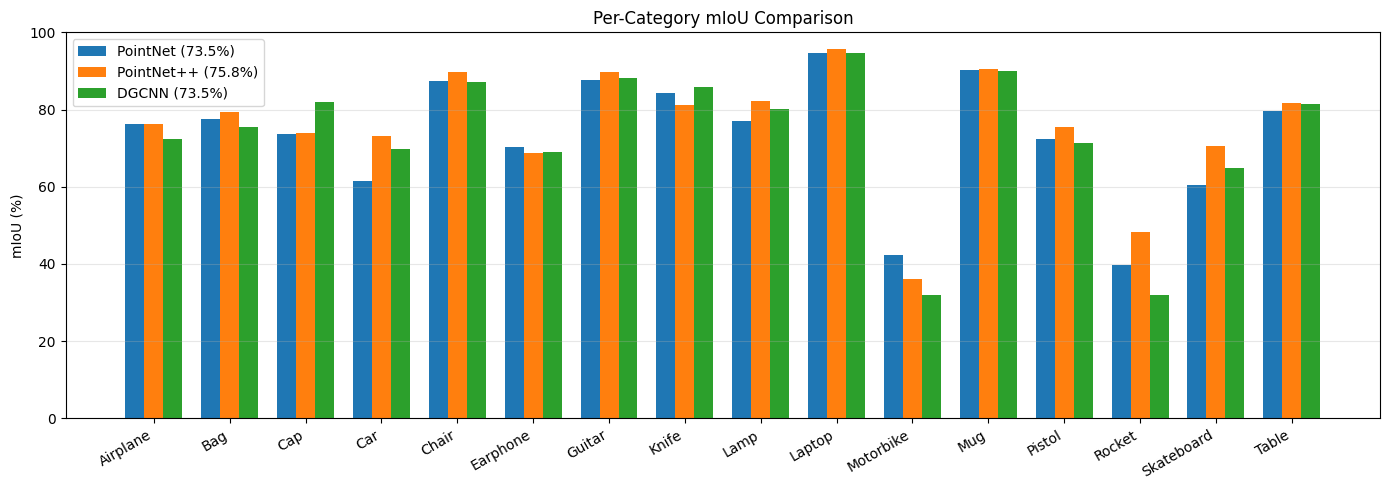

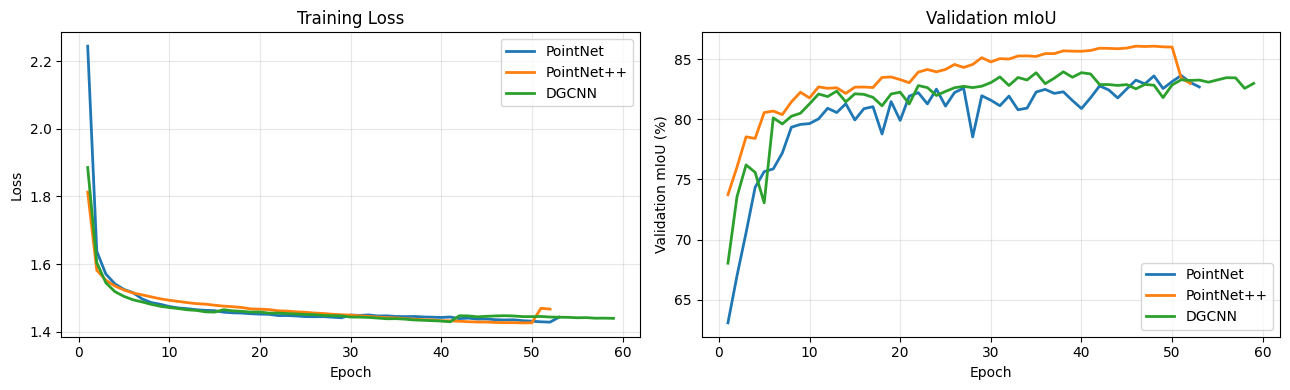


Figures saved to /kaggle/working/figures/


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

os.makedirs(os.path.join(SAVE_DIR, 'figures'), exist_ok=True)
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Figure 1: Per-category mIoU bar chart
cats = ALL_CATEGORIES
x = np.arange(len(cats))
w = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, r) in enumerate(results.items()):
    ious = [r['per_cat'].get(c, 0) * 100 for c in cats]
    ax.bar(x + i*w, ious, w, label=f'{name} ({np.mean(ious):.1f}%)', color=colors[i])
ax.set_xticks(x + w)
ax.set_xticklabels(cats, rotation=30, ha='right')
ax.set_ylabel('mIoU (%)')
ax.set_title('Per-Category mIoU Comparison')
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'per_cat_miou.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'per_cat_miou.png'), dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Training curves
histories = {'PointNet': history_pn, 'PointNet++': history_pn2, 'DGCNN': history_dgcnn}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for (name, h), c in zip(histories.items(), colors):
    ep = range(1, len(h['train_loss']) + 1)
    ax1.plot(ep, h['train_loss'], label=name, color=c, linewidth=2)
    ax2.plot(ep, [v*100 for v in h['val_miou']], label=name, color=c, linewidth=2)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax1.legend(); ax1.grid(alpha=0.3)
ax2.set(xlabel='Epoch', ylabel='Validation mIoU (%)', title='Validation mIoU')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'training_curves.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFigures saved to {os.path.join(SAVE_DIR, "figures")}/')

# Point Density Robustness (4th contribution / bonus)

Model             2048      1024       512       256       128
--------------------------------------------------------------
PointNet        79.94%    80.14%    80.05%    79.74%    79.02%
PointNet++      82.32%    81.78%    75.61%    60.86%    48.28%
DGCNN           80.46%    80.60%    77.04%    69.10%    62.40%


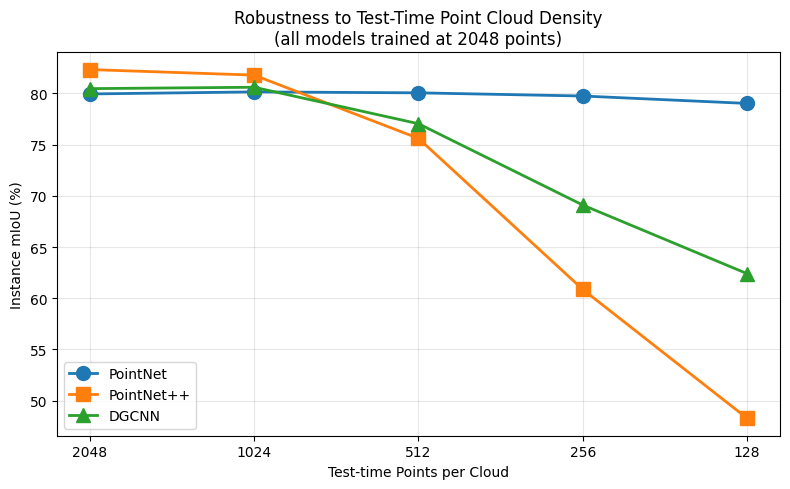


Key observation: a steeper drop = more reliance on dense local neighborhoods.
PointNet (global pooling) typically degrades more gracefully than
PointNet++ (fixed ball-query radii tuned for 2048-point density).


In [ ]:
# Re-evaluate model after randomly subsampling each cloud to n_points.
@torch.no_grad()
def evaluate_at_density(model, loader, n_points):
    model.eval()
    cat_ious = {i: [] for i in range(NUM_CATEGORIES)}
    for pts, lbl, cats, oh in loader:
        B, N, _ = pts.shape
        idx = torch.stack([torch.randperm(N)[:n_points] for _ in range(B)])
        batch_idx = torch.arange(B).unsqueeze(1).expand(-1, n_points)
        pts_sub = pts[batch_idx, idx]
        lbl_sub = lbl[batch_idx, idx]

        logits = model(pts_sub.to(DEVICE), oh.to(DEVICE))
        preds = logits.argmax(-1).cpu().numpy()
        lbl_np = lbl_sub.numpy()

        for b in range(preds.shape[0]):
            cat_ious[int(cats[b])].append(
                shape_iou(preds[b], lbl_np[b], int(cats[b])))

    all_ious = []
    for i in range(NUM_CATEGORIES):
        if cat_ious[i]:
            all_ious.extend(cat_ious[i])
    return float(np.mean(all_ious))


densities = [2048, 1024, 512, 256, 128]
density_results = {name: [] for name in models}

print(f'{"Model":<12}' + ''.join(f'{d:>10}' for d in densities))
print('-' * (12 + 10 * len(densities)))
for name, model in models.items():
    row = []
    for n in densities:
        miou = evaluate_at_density(model, test_loader, n)
        row.append(miou * 100)
        density_results[name].append(miou * 100)
    print(f'{name:<12}' + ''.join(f'{v:>9.2f}%' for v in row))

# Save numeric results
with open(os.path.join(SAVE_DIR, 'density_results.json'), 'w') as f:
    json.dump(density_results, f, indent=2)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
markers = ['o', 's', '^']
for (name, vals), c, m in zip(density_results.items(), colors, markers):
    ax.plot(densities, vals, marker=m, color=c, linewidth=2, markersize=10, label=name)
ax.set_xscale('log', base=2)
ax.set_xticks(densities)
ax.set_xticklabels([str(d) for d in densities])
ax.set_xlabel('Test-time Points per Cloud')
ax.set_ylabel('Instance mIoU (%)')
ax.set_title('Robustness to Test-Time Point Cloud Density\n(all models trained at 2048 points)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # high → low density reads left-to-right
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'density_robustness.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(SAVE_DIR, 'figures', 'density_robustness.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observation: a steeper drop = more reliance on dense local neighborhoods.')
print('PointNet (global pooling) typically degrades more gracefully than')
print('PointNet++ (fixed ball-query radii tuned for 2048-point density).')